# Study Area Definition — UNOSAT Ground Truth Coverage Analysis

**Project:** Deep Learning for Flood Inundation Mapping Using Multi-Source Satellite Data
**Study Area:** KwaZulu-Natal, South Africa
**Flood Event:** April 2022 KwaZulu-Natal Floods
**Reference Product:** UNOSAT FL20220418ZAF
**Author:** Valencia
**Supervisor:** Prof. Innocent Davidson
**Institution:** Cape Peninsula University of Technology (CPUT)

---

## Purpose of this Notebook

Before any satellite imagery is acquired, the spatial extent of the reference
ground truth must be established. This notebook determines the exact
geographic coverage of the UNOSAT FL20220418ZAF flood assessment product and
identifies which Sentinel-2 MGRS tile(s) are required to fully encompass it.

This is the first step in the data acquisition pipeline. Tile selection for
Sentinel-1 and Sentinel-2 imagery is derived directly from the output of this
notebook, rather than assumed in advance.

**Input:** `FL20220418ZAF.gdb` — UNOSAT File Geodatabase
**Output:** Consolidated water/flood extent layer, required MGRS tile list,
coverage map

---
## Step 1: Mount Drive and Load the UNOSAT Geodatabase

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install geopandas fiona --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 786.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 46.1 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import fiona
import warnings
warnings.filterwarnings('ignore')

GDB_PATH = '/content/drive/MyDrive/KZN_Research_Colab/Labels/FL20220418ZAF/FL20220418ZAF.gdb'

all_layers = fiona.listlayers(GDB_PATH)
print(f'Total layers in UNOSAT geodatabase: {len(all_layers)}')
for l in all_layers:
    print(' -', l)

Total layers in UNOSAT geodatabase: 56
 - Confidence_ID
 - Water_StatusID
 - Water_Class
 - Field_Validation
 - WV03_20220414_LandslideExtent_Durban
 - WV03_20220414_AffectedStructure_Durban
 - WV03_20220414_AnalysisExtent_Durban
 - NewSat_20220413_AnalysisExtent_eThekwiniMetroMunicipality_SouthAfrica
 - NewSat_20220413_DamageSites_eThekwiniMetroMunicipality_SouthAfrica
 - NewSat_20220413_DamageZones_eThekwiniMetroMunicipality_SouthAfrica
 - K3_20220421_AnalysisExtent_RayNkonyeni_Umzumbre
 - K3_20220421_LandslideExtent_RayNkonyeni_Umzumbre
 - S2_20220428_LandslideExtent_PineTown
 - S2_20220428_AnalysisExtent_PineTown
 - K3_20220421_AnalysisExtent_WestDurban
 - K3_20220421_WaterExtent_WestDurban
 - K3_20220421_LandslideExtent_WestDurban
 - K3_20220421_AffectedStructure_WestDurban
 - WV03_20220427_LandslideExtent_eThekwini_Umgungundlovu
 - WV03_20220427_AffectedStructure_eThekwini_Umgungundlovu
 - WV03_20220427_CloudObstruction_eThekwini_Umgungundlovu
 - WV03_20220427_AnalysisExtent_eThe

---
## Step 2: Identify Genuine Water/Flood Extent Layers

The UNOSAT package contains several categories of layer:

| Category | Examples | Represents |
|---|---|---|
| Water/Flood extent | `WaterExtent_*`, `FloodExtent_*` | Mapped surface water / flood inundation polygons |
| Analysis extent | `AnalysisExtent_*` | Boundary of the area UNOSAT analysts reviewed (not flood itself) |
| Affected structures | `AffectedStructure_*` | Point/building-level damage markers |
| Damage sites/zones | `DamageSites_*`, `DamageZones_*` | Infrastructure/landslide damage, not water |
| Landslide extent | `LandslideExtent_*` | Separate hazard type (mass movement, not flood water) |

For a flood inundation label, only the **water/flood extent** layers are
relevant. Analysis-extent, structure-damage, and landslide layers are
excluded — they answer a different question (where was reviewed, or what
was damaged) rather than where water was present.

In [ ]:
water_flood_layers = [l for l in all_layers if ('WaterExtent' in l or 'FloodExtent' in l)]

print('Water/flood extent layers identified:')
for l in water_flood_layers:
    print(' -', l)

Water/flood extent layers identified:
 - K3_20220421_WaterExtent_WestDurban
 - WV03_20220420_WaterExtent_Durban
 - WV03_20220420_WaterExtentDurban
 - WV03_20220420_FloodExtentDurban


---
## Step 3: Load Candidate Layers and Check for Duplicates

UNOSAT geodatabases can contain the same polygon exported more than once
under slightly different names (e.g. with or without an underscore). Each
candidate layer is checked for geometric duplication before merging, to
avoid double-counting the same flood area.

In [ ]:
loaded = {}
for l in water_flood_layers:
    gdf = gpd.read_file(GDB_PATH, layer=l).to_crs(epsg=4326)
    loaded[l] = gdf

print(f'{"Layer":<45} {"Features":>9} {"Area (ha)":>12}')
print('-' * 70)
for l, gdf in loaded.items():
    area_col = 'Area_ha' if 'Area_ha' in gdf.columns else None
    area = gdf[area_col].sum() if area_col else float('nan')
    print(f'{l:<45} {len(gdf):>9} {area:>12.2f}')

Layer                                          Features    Area (ha)
----------------------------------------------------------------------
K3_20220421_WaterExtent_WestDurban                    1        20.05
WV03_20220420_WaterExtent_Durban                      1       966.11
WV03_20220420_WaterExtentDurban                       1       966.11
WV03_20220420_FloodExtentDurban                       1        78.67


In [ ]:
# Pairwise geometric duplicate check
names = list(loaded.keys())
duplicates_found = []

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        gi = loaded[names[i]].geometry.unary_union
        gj = loaded[names[j]].geometry.unary_union
        if gi.is_empty or gj.is_empty:
            continue
        union_area = gi.union(gj).area
        if union_area == 0:
            continue
        iou = gi.intersection(gj).area / union_area
        if iou > 0.99:
            duplicates_found.append((names[i], names[j], iou))

if duplicates_found:
    print('Duplicate geometries detected (IoU > 0.99):')
    for a, b, iou in duplicates_found:
        print(f'  {a}  ==  {b}   (IoU={iou:.4f})')
else:
    print('No duplicate geometries detected among candidate layers.')

Duplicate geometries detected (IoU > 0.99):
  WV03_20220420_WaterExtent_Durban  ==  WV03_20220420_WaterExtentDurban   (IoU=1.0000)


---
## Step 4: Verify Flood-Water Classification Codes

UNOSAT's geodatabase includes a `Water_Class` domain table defining what
each numeric classification code represents (e.g. confirmed flood water,
possible flood water, pre-existing/baseline water). Pre-existing water
(`Water_Class = 0`, "Preflood Water") would not represent flood-induced
inundation and must be excluded if present.

Each candidate water/flood layer is checked against this lookup table
where the `Water_Class` field is available. Where a layer instead uses an
undocumented field (no corresponding lookup table found in the
geodatabase or in UNOSAT's public product documentation), this is
explicitly flagged rather than assumed.

In [ ]:
# Load the Water_Class domain/lookup table
water_class_lookup = gpd.read_file(GDB_PATH, layer='Water_Class')
print('UNOSAT Water_Class lookup table:')
print(water_class_lookup)
print()

PREFLOOD_CODE = 0  # 'Preflood Water' — pre-existing water, must be excluded if present

classification_report = []
for l in water_flood_layers:
    gdf = loaded[l]
    if 'Water_Class' in gdf.columns:
        codes = gdf['Water_Class'].dropna().unique().tolist()
        labels = water_class_lookup.set_index('Water_Class_code').loc[
            [c for c in codes if c in water_class_lookup['Water_Class_code'].values], 'Water_Class_txt'
        ].tolist() if codes else []
        status = 'EXCLUDE - preflood water' if PREFLOOD_CODE in codes else 'verified'
        classification_report.append((l, 'Water_Class', codes, labels, status))
    else:
        classification_report.append((l, 'none (undocumented field only)', [], [], 'UNVERIFIED'))

print(f'{"Layer":<42} {"Field":<14} {"Codes":<10} {"Meaning":<35} {"Status"}')
print('-' * 120)
for l, field, codes, labels, status in classification_report:
    print(f'{l:<42} {field:<14} {str(codes):<10} {str(labels):<35} {status}')

UNOSAT Water_Class lookup table:
   Water_Class_code                                    Water_Class_txt
0                 0                                     Preflood Water
1                 1                                        Flood Water
2                 2         Flood-Affected Land / Possible Flood water
3                 3                 Probable Flash Flood-Affected Land
4                 9                             Aquaculture (Wet Rice)
5                 6  Possible Saturated, wet Soil/ possible Flood W...
6                14                              Tsunami-Affected Land
7                99            Maximum Flood Water Extent (Cumulative)

Layer                                      Field          Codes      Meaning                             Status
------------------------------------------------------------------------------------------------------------------------
K3_20220421_WaterExtent_WestDurban         Water_Class    [2]        ['Flood-Affected Land / P

**Note on `WV03_20220420_WaterExtent_Durban`:**

This layer does not carry a `Water_Class` field. Its only classification
field, `Grouped_Damage_Classes` (value = 1), has no corresponding lookup
table in this geodatabase, and no public field dictionary defining this
code could be located in UNOSAT's published documentation for this product
(GLIDE FL20220418ZAF, Product ID 3543).

This layer is retained in the consolidated flood label for the following
reasons:
- It is named `WaterExtent_Durban` and was produced as part of the same
  official UNOSAT flood/landslide assessment package as the verified layers
- Its `SensorDate` (2022-04-21) and `EventCode` (FL20220418ZAF) place it
  within the same flood event and analysis window
- Its spatial extent (966 ha) is consistent with the scale of flooding
  reported for the April 2022 KwaZulu-Natal floods, one of South Africa's
  most severe recorded flood disasters

This is disclosed here as a known limitation: the semantic meaning of its
classification code could not be independently verified, and the layer is
included on the basis of its name, metadata, and contextual consistency
with the verified layers rather than a confirmed classification code.

No layer carries the `Preflood Water` code (0), so no exclusions are
required on classification grounds.

---
## Step 5: Build the Deduplicated Water/Flood Extent Layer

Where a duplicate pair is identified, only one copy is retained. The
remaining unique polygons are then combined into a single consolidated
water/flood extent dataset representing the full UNOSAT-mapped inundation
area for this event.

In [ ]:
# Resolve duplicates: keep the first-named layer in each duplicate pair, drop the rest
layers_to_drop = set()
for a, b, iou in duplicates_found:
    layers_to_drop.add(b)   # drop the second of each duplicate pair

final_layers = [l for l in water_flood_layers if l not in layers_to_drop]

print('Layers excluded as duplicates:')
for l in layers_to_drop:
    print(' -', l)
print()
print('Layers retained for the consolidated flood label:')
for l in final_layers:
    print(' -', l)

Layers excluded as duplicates:
 - WV03_20220420_WaterExtentDurban

Layers retained for the consolidated flood label:
 - K3_20220421_WaterExtent_WestDurban
 - WV03_20220420_WaterExtent_Durban
 - WV03_20220420_FloodExtentDurban


In [ ]:
# Merge retained layers into one GeoDataFrame with a consistent minimal schema
merged_records = []
for l in final_layers:
    gdf = loaded[l]
    for _, row in gdf.iterrows():
        merged_records.append({
            'source_layer': l,
            'area_ha': row.get('Area_ha', None),
            'geometry': row.geometry
        })

flood_gdf = gpd.GeoDataFrame(merged_records, crs='EPSG:4326')
total_area_ha = flood_gdf['area_ha'].sum()

print(f'Consolidated water/flood extent layer built.')
print(f'  Features      : {len(flood_gdf)}')
print(f'  Total area    : {total_area_ha:,.2f} ha')
print(f'  Source layers : {flood_gdf["source_layer"].nunique()}')

Consolidated water/flood extent layer built.
  Features      : 3
  Total area    : 1,064.82 ha
  Source layers : 3


---
## Step 6: Determine Geographic Extent of the Consolidated Flood Layer

In [ ]:
bounds = flood_gdf.total_bounds  # minx, miny, maxx, maxy (lon/lat)

print('Consolidated UNOSAT flood/water extent — bounding box (WGS84):')
print(f'  Min longitude : {bounds[0]:.4f}')
print(f'  Min latitude  : {bounds[1]:.4f}')
print(f'  Max longitude : {bounds[2]:.4f}')
print(f'  Max latitude  : {bounds[3]:.4f}')

Consolidated UNOSAT flood/water extent — bounding box (WGS84):
  Min longitude : 30.7711
  Min latitude  : -29.9543
  Max longitude : 31.0730
  Max latitude  : -29.7193


---
## Step 7: Identify Required Sentinel-2 MGRS Tile(s)

Each flood polygon's centroid is checked against the Sentinel-2 MGRS tiling
grid to determine which tile(s) it falls within. This identifies exactly
which Sentinel-2 (and correspondingly which Sentinel-1, since both follow
comparable swath geometry) tiles must be acquired to fully cover the
UNOSAT-mapped flood extent — rather than assuming a single tile in
advance.

In [ ]:
!pip install mgrs --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 1.2 MB/s eta 0:00:00


In [ ]:
import mgrs
m = mgrs.MGRS()

flood_gdf['centroid'] = flood_gdf.geometry.centroid
flood_gdf['mgrs_tile'] = flood_gdf['centroid'].apply(
    lambda pt: m.toMGRS(pt.y, pt.x, MGRSPrecision=0)
)

tile_counts = flood_gdf['mgrs_tile'].value_counts()
print('MGRS tile distribution across consolidated flood polygons:')
print(tile_counts)
print()
required_tiles = sorted(tile_counts.index.tolist())
print('Required Sentinel-2 tiles for full UNOSAT coverage:', required_tiles)

MGRS tile distribution across consolidated flood polygons:
mgrs_tile
36JUM    2
36JTM    1
Name: count, dtype: int64

Required Sentinel-2 tiles for full UNOSAT coverage: ['36JTM', '36JUM']


---
## Step 8: Visualise Coverage — Flood Extent vs Tile Footprint

A visual check confirms the numerical tile assignment above and shows how
much of each required tile is actually needed.

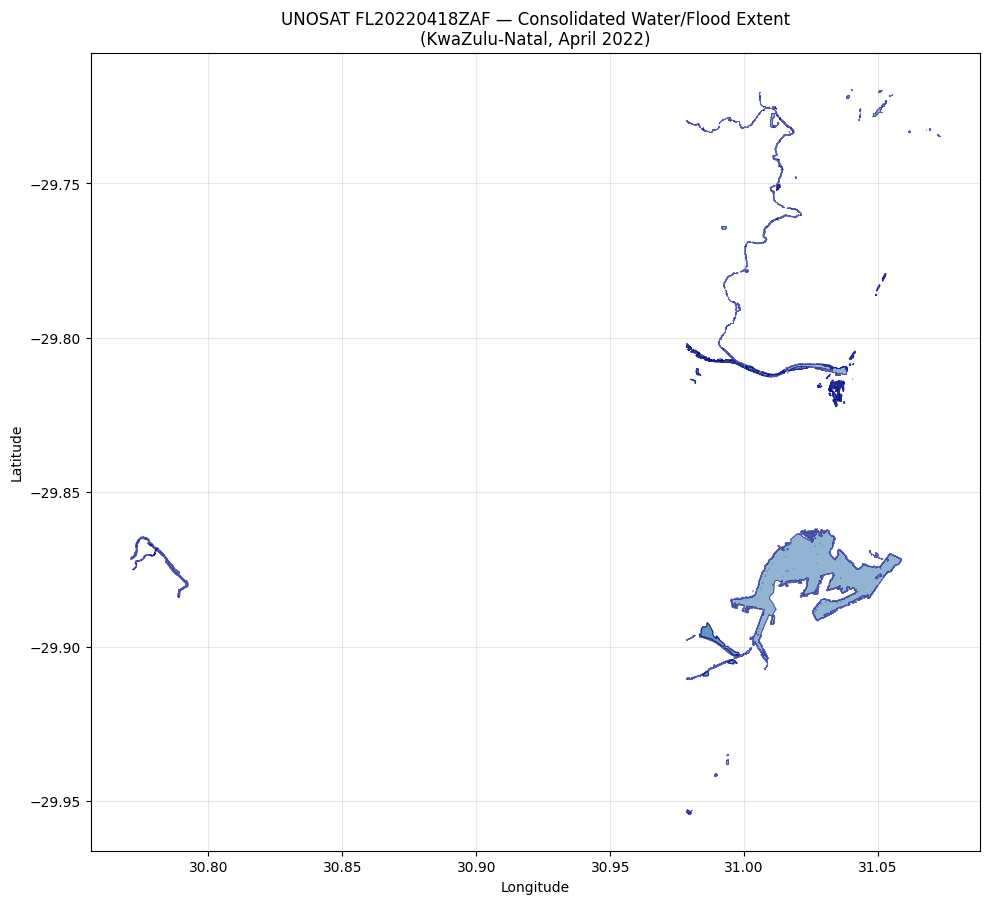

Map saved: unosat_flood_extent_map.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

flood_gdf.plot(ax=ax, color='steelblue', edgecolor='navy', alpha=0.6, linewidth=0.8)

ax.set_title('UNOSAT FL20220418ZAF — Consolidated Water/Flood Extent\n(KwaZulu-Natal, April 2022)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/unosat_flood_extent_map.png', dpi=150)
plt.show()

print('Map saved: unosat_flood_extent_map.png')

---
## Step 9: Summary — Study Area Definition Outcome

This summary becomes the documented justification for tile selection in the
methodology, rather than an assumption made before checking the ground
truth.

In [ ]:
print('=' * 65)
print('STUDY AREA DEFINITION — SUMMARY')
print('=' * 65)
print(f'  UNOSAT product           : FL20220418ZAF')
print(f'  Water/flood layers used  : {len(final_layers)}')
for l in final_layers:
    print(f'    - {l}')
print(f'  Duplicate layers excluded: {len(layers_to_drop)}')
print(f'  Total flood/water area   : {total_area_ha:,.2f} ha')
print(f'  Bounding box (WGS84)     : {bounds}')
print(f'  Required MGRS tiles      : {required_tiles}')
print()
print('Next step: acquire Sentinel-2 and Sentinel-1 imagery for the')
print('tile(s) identified above, with dates selected based on cloud')
print('cover / SAR pass availability (documented in the next notebook).')

STUDY AREA DEFINITION — SUMMARY
  UNOSAT product           : FL20220418ZAF
  Water/flood layers used  : 3
    - K3_20220421_WaterExtent_WestDurban
    - WV03_20220420_WaterExtent_Durban
    - WV03_20220420_FloodExtentDurban
  Duplicate layers excluded: 1
  Total flood/water area   : 1,064.82 ha
  Bounding box (WGS84)     : [ 30.77109623 -29.95431771  31.07295343 -29.71934404]
  Required MGRS tiles      : ['36JTM', '36JUM']

Next step: acquire Sentinel-2 and Sentinel-1 imagery for the
tile(s) identified above, with dates selected based on cloud
cover / SAR pass availability (documented in the next notebook).


In [ ]:
# Save the consolidated flood vector layer for use in later notebooks
import os
OUT_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Labels_v2/'
os.makedirs(OUT_DIR, exist_ok=True)

flood_gdf.drop(columns=['centroid']).to_file(
    OUT_DIR + 'UNOSAT_flood_extent_consolidated.geojson', driver='GeoJSON'
)
print('Saved consolidated flood extent to:')
print(' ', OUT_DIR + 'UNOSAT_flood_extent_consolidated.geojson')

Saved consolidated flood extent to:
  /content/drive/MyDrive/KZN_Research_Colab/Labels_v2/UNOSAT_flood_extent_consolidated.geojson
